## Import Packages

In [1]:
# general
import numpy as np
import pandas as pd
import os
from tqdm.notebook import tqdm # if this line throws an error, type "conda install tqdm" in your terminal to install tqdm

# plotting
import matplotlib
import matplotlib.pyplot as plt

# my functions/classes
import sys
sys.path.append("../core_scripts/")
from ECMclass import ECM

## User Inputs

In [2]:
# smoothing window, mm
window = 10

# paths
global path_to_data, path_to_figures, path_to_metadata, metadata_file
path_to_data = '../../data/'
path_to_figures = '../../figures/average_oneline/'
path_to_metadata = '../../data/'
metadata_file = 'metadata.csv'

In [3]:
# set globals
global meta, my_cmap

# Load metadata
meta = pd.read_csv(path_to_data+metadata_file)

# make colormap
my_cmap = matplotlib.colormaps['Spectral']

## Functions

In [4]:
def get_ave(depth,meas,surf_imperf):

    # get min/max
    min_depth = round(min(depth),2)
    max_depth = round(max(depth),2)

    # make new depth array with 0.01 m spacing
    d = np.linspace(min_depth,max_depth,int((max_depth-min_depth)*100+1))

    # filter meas and depth for only vlaues where surf_imperf is 0 (no surface imperfection)
    depth = np.array([depth[i] for i in range(len(depth)) if surf_imperf[i] == 0])
    meas = np.array([meas[i] for i in range(len(meas)) if surf_imperf[i] == 0])

        # sort depth and meas
    depth, meas = zip(*sorted(zip(depth, meas)))

    # get average of the measurements of elements in the list with index between lo and hi-1
    m_mean = []
    m_median = []
    m_std = []
    lo = 0
    hi = 0
    for i in range(len(d)):

        # set lo and hi to the indices of the measurements that are within 0.005 m of the current depth value
        lo = hi

        while hi<len(depth) and depth[hi] < d[i] + 0.005:
            hi += 1

        # get average of the measurements of elements in the list with index between lo and hi-1
        m_mean.append(np.mean(meas[lo:hi-1]))
        m_median.append(np.median(meas[lo:hi-1]))
        m_std.append(np.std(meas[lo:hi-1]))



    return d,m_mean,m_median,m_std

In [5]:
def make_plot(core,df):

    # Make a simple plot
    print("Making simple plot for core: "+core)
    fig, ax = plt.subplots(1,2,figsize=(7, 10))
    ax[0].plot(df['AC_median'], df['depth'], label='AC')
    # ax[0].fill_betweenx(
    #     df['depth'],
    #     np.maximum(df['AC_median'] - df['AC_std'], np.finfo(float).eps),
    #     df['AC_median'] + df['AC_std'],
    #     alpha=0.5,
    #     label='±1 std'
    # )
    ax[1].plot(df['DC_median'], df['depth'], label='DC')
    # ax[1].fill_betweenx(
    #     df['depth'],
    #     np.maximum(df['DC_median'] - df['DC_std'], np.finfo(float).eps),
    #     df['DC_median'] + df['DC_std'],
    #     alpha=0.5,
    #     label='±1 std'
    # )

    # housekeeping
    ax[0].legend()
    ax[1].set_xscale('log')
    ax[0].set_xlabel('AC Current (amps)')
    ax[1].set_xlabel('DC Current (amps)')
    ax[0].set_ylabel('Depth (m)')
    ax[0].set_title('AC Measurements')
    ax[1].set_title('DC Measurements')
    ax[0].set_ylim(round(max(df['depth'])+1), round(min(df['depth']))-1)
    ax[1].set_ylim(round(max(df['depth'])+1), round(min(df['depth']))-1)

    plt.subplots_adjust(wspace=0.1)
    ax[1].set_yticklabels([])
    ax[1].set_yticks([])
    plt.show()

    # # Set xlim for AC plot based on median range
    # ax[0].set_xlim([round(min(df['AC_median'])/10), round(max(df['AC_median'])*10)])

    # # set fixed xlim for DC plot to be between 10^-9 and 10^-5
    # ax[1].set_xlim([10**-9, 10**-5])

    # save figure to figures folder
    fig.savefig(path_to_figures+core+'/'+core+'_oneline.png', dpi=300, bbox_inches='tight')

In [6]:
def make_oneline(core):

    # check that path_to_figures+core exists, if not create it
    if not os.path.exists(path_to_figures+core):
        os.makedirs(path_to_figures+core)

    all_DC = np.array([])
    all_DC_depth = np.array([])
    all_DC_surf_imperf = np.array([])
    all_AC = np.array([])
    all_AC_depth = np.array([])
    all_AC_surf_imperf = np.array([])


    # filter metadata for the core of interest
    core_meta = meta[meta['core'] == core]

    # load all core data
    print("Loading data for core: "+core)
    for index, row in tqdm(
        core_meta.iterrows(),
        total=len(core_meta),
        desc=f"Loading {core}",
    ):

        # check if filename exists in ../../data/clean/[core]/
        if os.path.exists(path_to_data+'clean/'+row['core']+'/'+row['core']+'-'+row['section']+'-'+row['face']+'-'+row['ACorDC']+'.csv'):
            path_to_file = path_to_data+'clean/'
        else:
            path_to_file = path_to_data+'not-cleaned/'
        data_item = ECM(row['core'],row['section'],row['face'],row['ACorDC'],path_to_file,path_to_metadata + metadata_file)
        data_item.rem_ends(30)
        data_item.norm_outside()

        if data_item.ACorDC == 'AC':
            # debugging - print the shape of all_AC and data_item.meas
            #print(f"all_AC shape: {all_AC.shape}, data_item.meas shape: {data_item.meas.shape}, data_item.surface_imperfection shape: {data_item.surface_imperfection.shape}")
            all_AC = np.append(all_AC,data_item.meas)
            all_AC_depth = np.append(all_AC_depth,data_item.depth)
            all_AC_surf_imperf = np.append(all_AC_surf_imperf,data_item.surface_imperfection)
        else:
            all_DC = np.append(all_DC,data_item.meas)
            all_DC_depth = np.append(all_DC_depth,data_item.depth)
            all_DC_surf_imperf = np.append(all_DC_surf_imperf,data_item.surface_imperfection)

    # get average of all AC and DC measurements
    print("Calculating average AC measurements for core: "+core)
    d_AC, m_AC_mean, m_AC_median, m_AC_std = get_ave(all_AC_depth,all_AC,all_AC_surf_imperf)
    print("Calculating average DC measurements for core: "+core)
    d_DC, m_DC_mean, m_DC_median, m_DC_std = get_ave(all_DC_depth,all_DC,all_DC_surf_imperf)

    # make dataframe with depth and average measurements
    ac_df = pd.DataFrame({"depth": np.round(d_AC, 2), "AC": m_AC_mean, "AC_median": m_AC_median, "AC_std": m_AC_std})
    dc_df = pd.DataFrame({"depth": np.round(d_DC, 2), "DC": m_DC_mean, "DC_median": m_DC_median, "DC_std": m_DC_std})
    df = (
        pd.merge(ac_df, dc_df, on="depth", how="outer")
        .sort_values("depth")
        .reset_index(drop=True)
    )
    # sort oneline dataframe by depth
    df = df.sort_values(by='depth')

    # make plot of the oneline data
    make_plot(core,df)

    # save dataframe to outputs folder as csv, fill empty values with NaN, and do not include index
    df.to_csv(path_to_data+'processed/'+core+'_oneline.csv',index=False,na_rep='NaN')
    

Loading data for core: ALHIC2302


Loading ALHIC2302:   0%|          | 0/304 [00:00<?, ?it/s]

Calculating average AC measurements for core: ALHIC2302


/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Calculating average DC measurements for core: ALHIC2302
Making simple plot for core: ALHIC2302


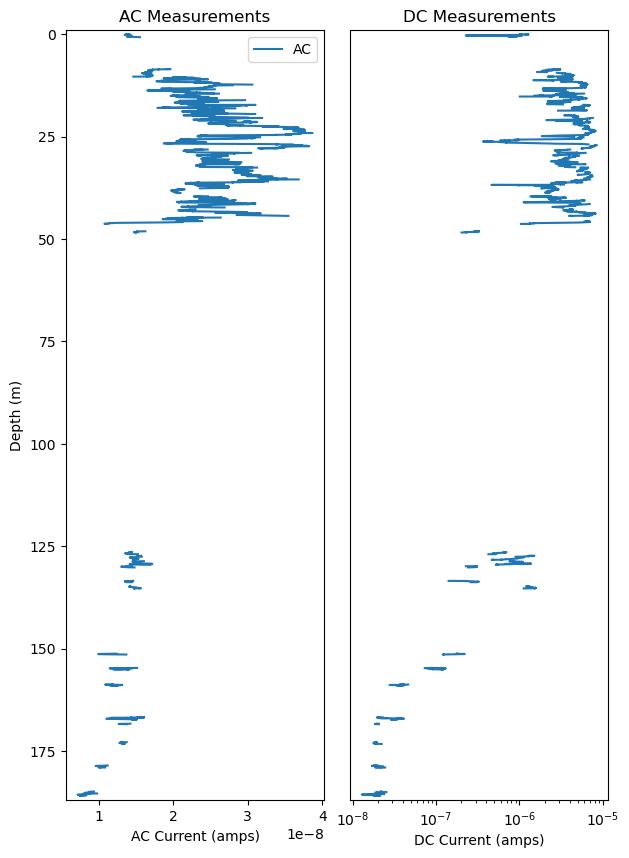

In [7]:
make_oneline('ALHIC2302')

Loading data for core: ALHIC2416


Loading ALHIC2416:   0%|          | 0/45 [00:00<?, ?it/s]

Calculating average AC measurements for core: ALHIC2416
Calculating average DC measurements for core: ALHIC2416


/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Making simple plot for core: ALHIC2416


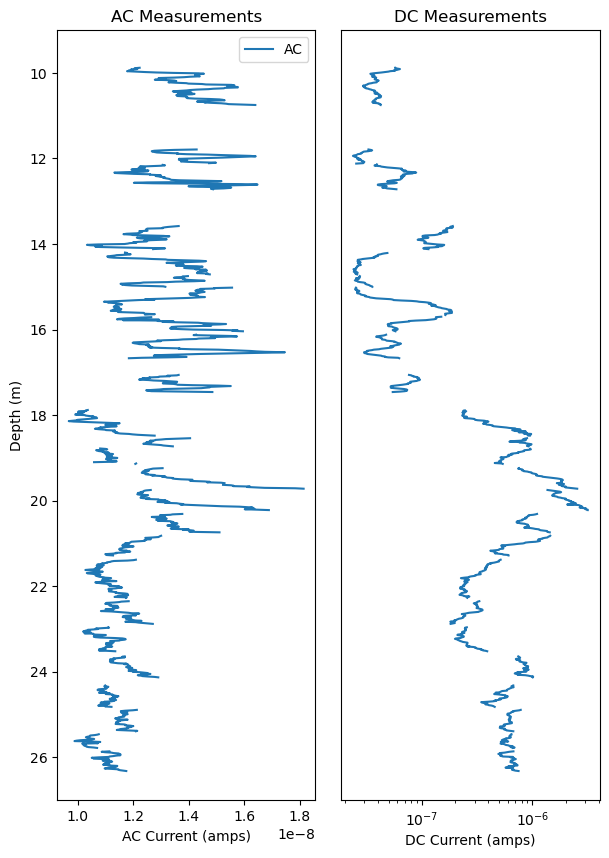

In [8]:
make_oneline('ALHIC2416')

Loading data for core: ALHIC2501


Loading ALHIC2501:   0%|          | 0/378 [00:00<?, ?it/s]

Calculating average AC measurements for core: ALHIC2501


/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Calculating average DC measurements for core: ALHIC2501
Making simple plot for core: ALHIC2501


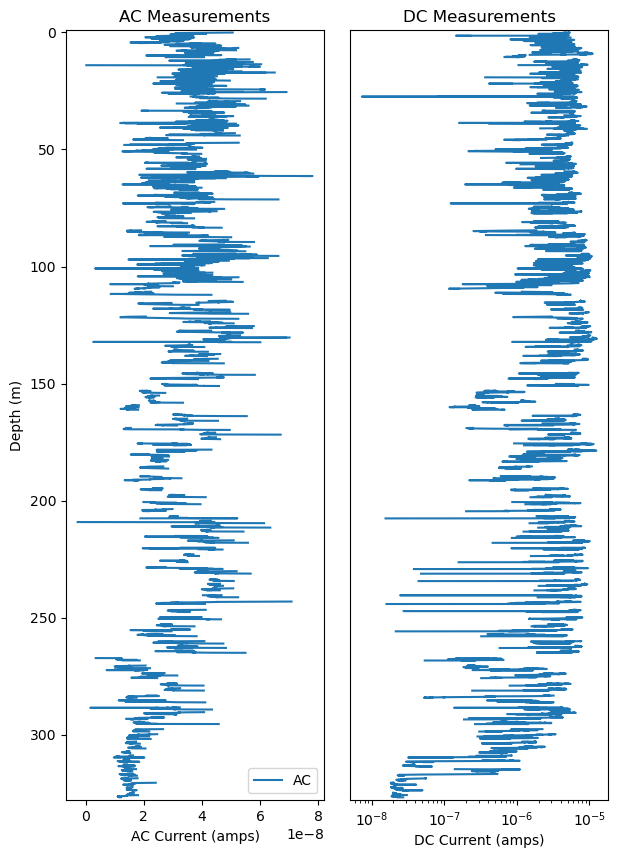

In [9]:
make_oneline('ALHIC2501')

Loading data for core: ALHIC2301


Loading ALHIC2301:   0%|          | 0/82 [00:00<?, ?it/s]

/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Calculating average AC measurements for core: ALHIC2301


/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Calculating average DC measurements for core: ALHIC2301
Making simple plot for core: ALHIC2301


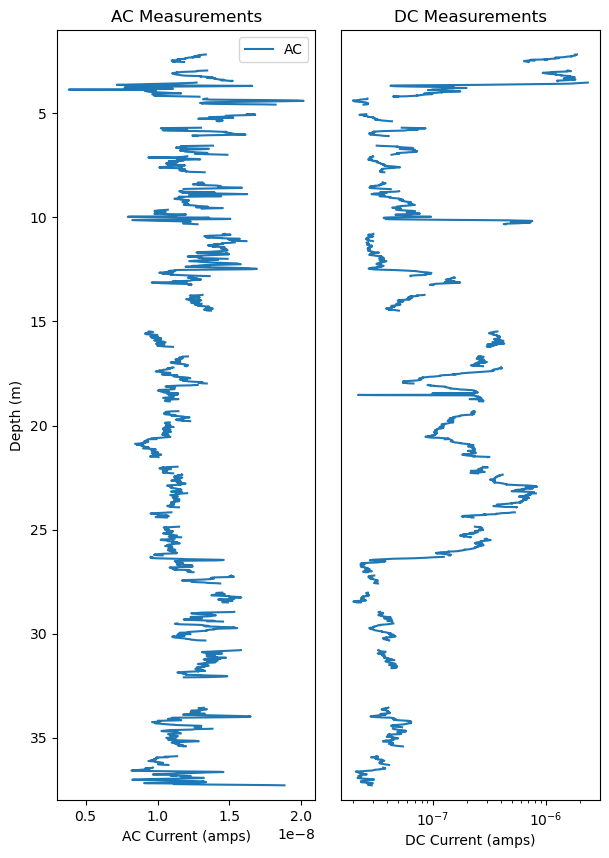

In [10]:
make_oneline('ALHIC2301')

Loading data for core: ALHIC2401


Loading ALHIC2401:   0%|          | 0/155 [00:00<?, ?it/s]

Calculating average AC measurements for core: ALHIC2401


/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Calculating average DC measurements for core: ALHIC2401
Making simple plot for core: ALHIC2401


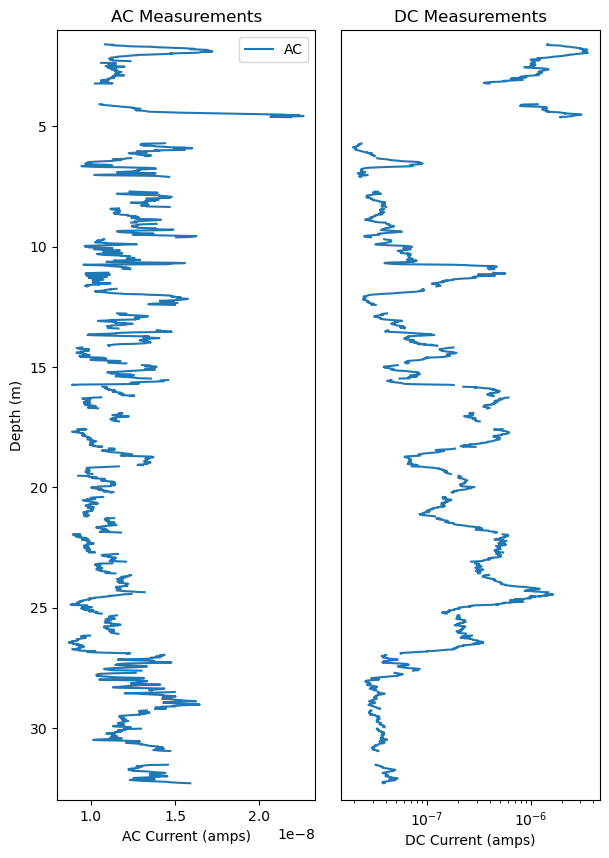

In [11]:
make_oneline('ALHIC2401')

In [ ]:
make_oneline('ALHIC2201')

Loading data for core: ALHIC2201


Loading ALHIC2201:   0%|          | 0/93 [00:00<?, ?it/s]

/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13

Calculating average AC measurements for core: ALHIC2201


/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/Liam/anaconda3/envs/COLDEX_ECM/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
make_oneline('ALHIC2502')